
# Paso 00 — Recorte geográfico y masas por nodo (Tareas 0-1)

Primer bloque de la generación de demanda: bajar de "toda Noruega" a los 4 nodos
de demanda, y sumar población y empleo dentro del radio de captación de cada uno.

**Qué hace este notebook:**
1. Inspecciona las 2 grillas SSB crudas (columnas, CRS, resolución, cobertura) — Tarea 0.
2. Recorta ambas a un bbox Bergen + Askøy, cachea el recorte — Tarea 0.
3. Para cada nodo, suma población y empleo de las celdas cuyo centro cae dentro
   del radio de captación configurado — Tarea 1.
4. Genera mapas de verificación por nodo.


In [1]:

import sys
import time
from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd
import pyogrio
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent / "src"))
import masas
import plotting

BASE_DIR = Path.cwd().parent
CONFIG_PATH = BASE_DIR / "config" / "instance.yaml"
OUTPUT_DIR = BASE_DIR / "output"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
OUTPUT_DIR.mkdir(exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110

cfg = masas.cargar_config(CONFIG_PATH)
cfg


{'fuentes_externas': {'nodos_config': '../bergen-boats/config/instance.yaml',
  'matriz_tiempos_min': '../bergen-boats/02_ruteo_navegable/output/matriz_tiempos_min.csv'},
 'datos_ssb': {'poblacion_geojson': 'data/2026-08-18-befolkning_250m_2026.geojson',
  'poblacion_columna': 'pop_tot',
  'bedrifter_geojson': 'data/2026-08-18-bedrifter_250m_2026.geojson',
  'empleo_columna': 'emp_tot',
  'establecimientos_columna': 'est_tot',
  'crs_grilla': 'EPSG:32633',
  'resolucion_celda_m': 250,
  'fuente_poblacion_cita': 'PENDIENTE: confirmar URL/nombre exacto del dataset SSB de origen',
  'fuente_bedrifter_cita': 'PENDIENTE: confirmar URL/nombre exacto del dataset SSB de origen'},
 'recorte': {'margen_bbox_m': 8000},
 'captacion': {'radio_m': 1000},
 'masas': {'normalizacion': 'max',
  'factor_universitario': {'kleppesto': 0.5,
   'laksevag': 0.7,
   'bryggen': 1.0,
   'sandviken': 1.0}},
 'franjas_horarias': [{'id': 'manana',
   'horas': [6, 9],
   'factor_volumen': 1.0,
   'rol_origen': 'pobl

## Tarea 0a — Inspección de las grillas SSB crudas

Metadatos leídos directo del archivo (sin cargar las ~360 mil filas), con
`pyogrio.read_info`: columnas, tipos, CRS, número de features y bbox total.


In [2]:

pop_path = BASE_DIR / cfg["datos_ssb"]["poblacion_geojson"]
bedrifter_path = BASE_DIR / cfg["datos_ssb"]["bedrifter_geojson"]

for etiqueta, path in [("Población (befolkning_250m)", pop_path), ("Bedrifter/empleo (bedrifter_250m)", bedrifter_path)]:
    info = pyogrio.read_info(str(path))
    print(f"=== {etiqueta} ===")
    print(f"  archivo: {path.name}  ({path.stat().st_size/1e6:.1f} MB)")
    print(f"  CRS: {info['crs']}")
    print(f"  columnas: {list(info['fields'])}  (tipos: {list(info['dtypes'])})")
    print(f"  tipo de geometría: {info['geometry_type']}")
    print(f"  nº de features (todo Noruega): {info['features']:,}")
    print(f"  bbox total (EPSG:32633): {tuple(round(v) for v in info['total_bounds'])}")
    print()


=== Población (befolkning_250m) ===
  archivo: 2026-08-18-befolkning_250m_2026.geojson  (77.7 MB)
  CRS: EPSG:32633
  columnas: ['ssbid250m', 'pop_tot']  (tipos: ['int64', 'int32'])
  tipo de geometría: MultiPolygon
  nº de features (todo Noruega): 225,238
  bbox total (EPSG:32633): (-75000, 6451000, 1098500, 7938000)

=== Bedrifter/empleo (bedrifter_250m) ===
  archivo: 2026-08-18-bedrifter_250m_2026.geojson  (48.0 MB)
  CRS: EPSG:32633
  columnas: ['SSBID250M', 'est_tot', 'emp_tot']  (tipos: ['int64', 'int32', 'int32'])
  tipo de geometría: MultiPolygon
  nº de features (todo Noruega): 133,688
  bbox total (EPSG:32633): (-74750, 6451250, 1098250, 7938000)



**Hallazgos, para dejar documentados (ver `../README.md` para el detalle):**
- CRS confirmado: **EPSG:32633** (UTM 33N) en ambos archivos — es un CRS métrico, correcto para radios de captación en metros.
- `befolkning_250m`: columnas `ssbid250m` (id de celda) y `pop_tot` (población total de la celda). Cubre toda Noruega (225 238 celdas).
- `bedrifter_250m`: columnas `SSBID250M`, `est_tot` (nº de establecimientos) y **`emp_tot` (empleo real, no solo conteo de empresas)**. 133 688 celdas.
- Resolución: se verifica abajo con el tamaño real de una celda (debe dar 250×250 m exactos).


In [3]:

# Verificación de resolución: tamaño real de una celda de muestra (primeras 3 filas).
muestra = gpd.read_file(pop_path, rows=3)
for geom in muestra.geometry:
    xmin, ymin, xmax, ymax = geom.bounds
    print(f"celda: ancho={xmax-xmin:.2f} m, alto={ymax-ymin:.2f} m")


celda: ancho=250.00 m, alto=250.00 m
celda: ancho=250.00 m, alto=250.00 m
celda: ancho=250.00 m, alto=250.00 m


## Tarea 0b — Nodos y bounding box de recorte

Se cargan los 4 nodos desde `bergen-boats/config/instance.yaml` (única fuente
de verdad de las coordenadas) y se calcula el bbox de recorte: el rectángulo
que cubre los 4 nodos, con un margen (`recorte.margen_bbox_m`) que deja espacio
de sobra para cualquier radio de captación razonable.


In [4]:

nodos_utm = masas.cargar_nodos(cfg, BASE_DIR)
print(nodos_utm[["nombre"]])
print()

bbox = masas.bbox_bergen_askoy(nodos_utm, cfg["recorte"]["margen_bbox_m"])
xmin, ymin, xmax, ymax = bbox
print(f"Bbox de recorte (EPSG:32633): xmin={xmin:.1f}, ymin={ymin:.1f}, xmax={xmax:.1f}, ymax={ymax:.1f}")
print(f"Ancho: {(xmax-xmin)/1000:.2f} km, Alto: {(ymax-ymin)/1000:.2f} km")


                            nombre
id                                
kleppesto        Kleppestø (Askøy)
laksevag        Laksevåg (Gravdal)
bryggen          Bryggen / Sentrum
sandviken  Sandviken (BSI Padling)

Bbox de recorte (EPSG:32633): xmin=-45041.1, ymin=6726620.1, xmax=-24044.2, ymax=6745676.7
Ancho: 21.00 km, Alto: 19.06 km


## Tarea 0c — Recorte y caché

Se recorta cada grilla al bbox de arriba (solo celdas cuyo **centro** cae
dentro, mismo criterio que se usará para el radio de captación) y se cachea
como GeoParquet en `data/processed/` — si el caché ya existe, no se repite el
recorte.


In [5]:

t0 = time.time()
pop_recortada = masas.recortar_grilla(
    pop_path, bbox, PROCESSED_DIR / "poblacion_bergen_askoy.parquet",
)
bedrifter_recortada = masas.recortar_grilla(
    bedrifter_path, bbox, PROCESSED_DIR / "bedrifter_bergen_askoy.parquet",
)
print(f"Listo en {time.time()-t0:.1f} s")
print(f"Celdas de población tras recorte: {len(pop_recortada):,} (de 225,238 en todo el país)")
print(f"Celdas de bedrifter tras recorte: {len(bedrifter_recortada):,} (de 133,688 en todo el país)")
print(f"Población total en el bbox recortado: {pop_recortada['pop_tot'].sum():,}")
print(f"Empleo total en el bbox recortado: {bedrifter_recortada['emp_tot'].sum():,}")


Listo en 1.2 s
Celdas de población tras recorte: 2,557 (de 225,238 en todo el país)
Celdas de bedrifter tras recorte: 2,127 (de 133,688 en todo el país)
Población total en el bbox recortado: 260,168
Empleo total en el bbox recortado: 160,895


## Tarea 1 — Masas por nodo (radio de captación)

Para cada nodo: círculo de radio `captacion.radio_m` (inicial 1000 m) alrededor
del nodo, y suma de población/empleo de las celdas cuyo **centro** cae dentro
—no se usa la celda del muelle, se usa el área que la parada sirve caminando.


In [6]:

resumen, celdas_pop_por_nodo, celdas_emp_por_nodo = masas.calcular_masas_por_nodo(
    cfg, nodos_utm, pop_recortada, bedrifter_recortada
)
resumen


,nombre,radio_m,n_celdas_poblacion,poblacion_total,poblacion_min_celda,poblacion_max_celda,poblacion_media_celda,poblacion_mediana_celda,n_celdas_bedrifter,establecimientos_total,empleo_total,empleo_min_celda,empleo_max_celda,empleo_media_celda,empleo_mediana_celda
id,,,,,,,,,,,,,,,
kleppesto,Kleppestø (Askøy),1000,27,2177,7,201,80.63,69.0,25,207,1922,0,444,76.88,8.0
laksevag,Laksevåg (Gravdal),1000,23,2321,2,243,100.91,113.0,23,239,1655,0,321,71.96,27.0
bryggen,Bryggen / Sentrum,1000,41,18602,1,1304,453.71,348.0,46,5414,35333,0,3292,768.11,423.5
sandviken,Sandviken (BSI Padling),1000,27,5291,1,617,195.96,208.0,28,432,2858,0,955,102.07,14.0


In [7]:

resumen.to_csv(OUTPUT_DIR / "masas_por_nodo.csv")
print("Guardado:", OUTPUT_DIR / "masas_por_nodo.csv")


Guardado: c:\Users\hfons\Andes\OneDrive - Universidad de los Andes\NHH\NHH-Schedule-Free-Autonomous-Boats-in-Bergen\demand\output\masas_por_nodo.csv


### Estadísticas descriptivas por celda, por nodo

Min, máx, media y mediana de población y empleo **por celda** dentro del radio
de cada nodo — para ver si la masa está concentrada en pocas celdas densas o
repartida.


In [8]:

resumen[[
    "n_celdas_poblacion", "poblacion_total", "poblacion_min_celda", "poblacion_media_celda",
    "poblacion_mediana_celda", "poblacion_max_celda",
]]


,n_celdas_poblacion,poblacion_total,poblacion_min_celda,poblacion_media_celda,poblacion_mediana_celda,poblacion_max_celda
id,,,,,,
kleppesto,27,2177,7,80.63,69.0,201
laksevag,23,2321,2,100.91,113.0,243
bryggen,41,18602,1,453.71,348.0,1304
sandviken,27,5291,1,195.96,208.0,617


In [9]:

resumen[[
    "n_celdas_bedrifter", "establecimientos_total", "empleo_total", "empleo_min_celda",
    "empleo_media_celda", "empleo_mediana_celda", "empleo_max_celda",
]]


,n_celdas_bedrifter,establecimientos_total,empleo_total,empleo_min_celda,empleo_media_celda,empleo_mediana_celda,empleo_max_celda
id,,,,,,,
kleppesto,25,207,1922,0,76.88,8.0,444
laksevag,23,239,1655,0,71.96,27.0,321
bryggen,46,5414,35333,0,768.11,423.5,3292
sandviken,28,432,2858,0,102.07,14.0,955


## Mapas de verificación por nodo

Círculo de captación + celdas de población (verde, relleno) y de empleo (rojo,
achurado) resaltadas sobre el mapa real — para revisar visualmente que el
radio tiene sentido y que los 4 círculos no se traslapan de forma rara.


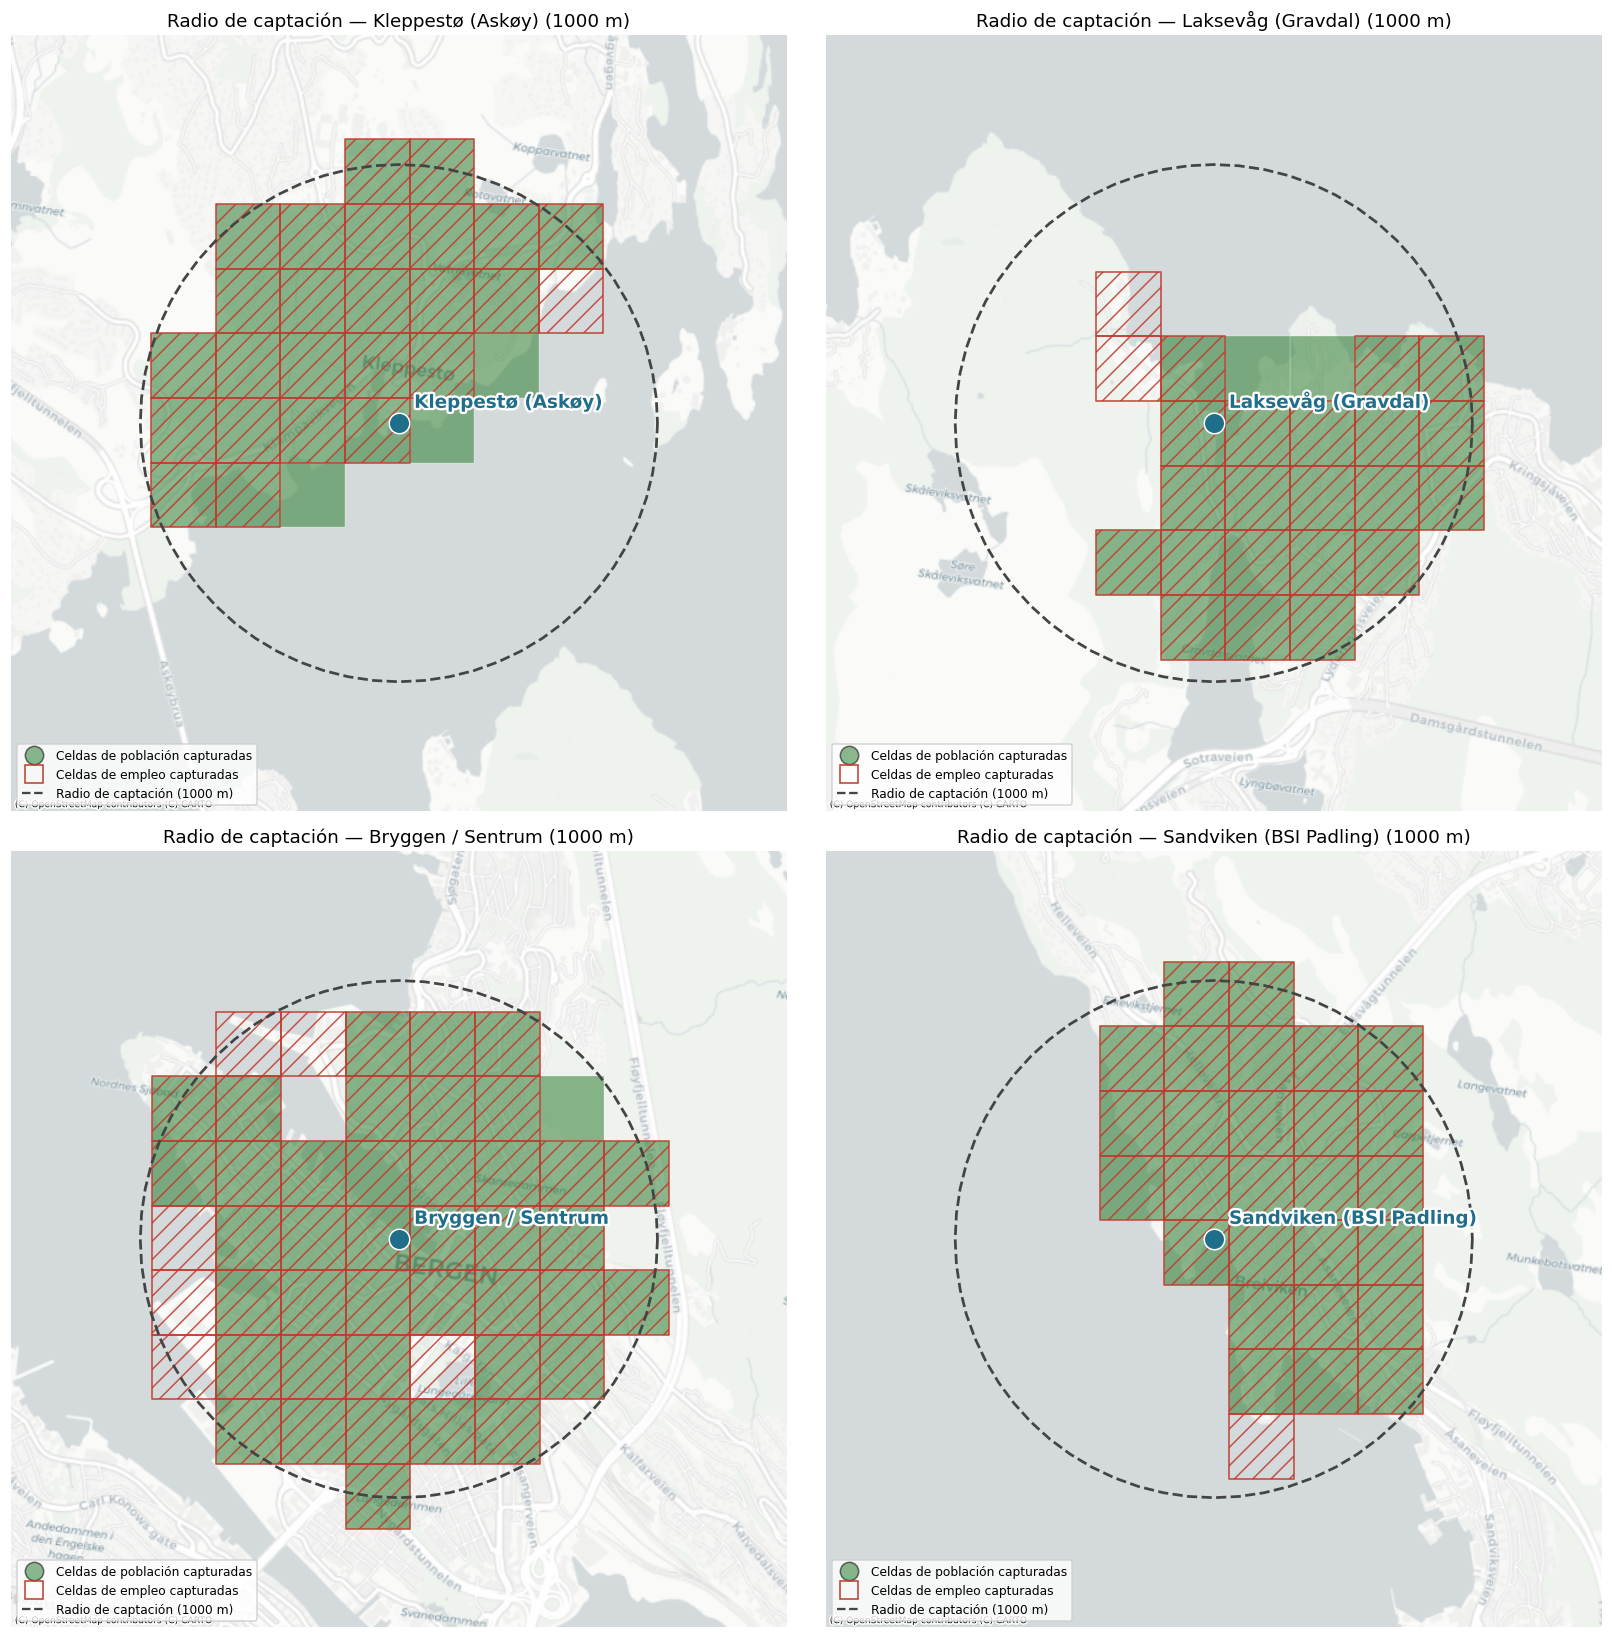

In [10]:

fig, axes = plt.subplots(2, 2, figsize=(15, 15))
for ax, (nid, row) in zip(axes.flat, nodos_utm.iterrows()):
    plotting.mapa_captacion_nodo(
        row["nombre"], row.geometry, cfg["captacion"]["radio_m"],
        celdas_pop_por_nodo[nid], celdas_emp_por_nodo[nid], ax=ax,
    )
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mapas_captacion_4_nodos.png", dpi=180, bbox_inches="tight")
plt.show()


### ¿Se traslapan los radios de captación entre nodos?

Chequeo directo: distancia entre cada par de nodos vs. la suma de sus dos
radios de captación (si la distancia es menor, los círculos se tocan).


In [11]:

import itertools

radio_m = cfg["captacion"]["radio_m"]
filas_chk = []
for a, b in itertools.combinations(nodos_utm.index, 2):
    dist = nodos_utm.loc[a, "geometry"].distance(nodos_utm.loc[b, "geometry"])
    filas_chk.append({
        "par": f"{nodos_utm.loc[a,'nombre']} <-> {nodos_utm.loc[b,'nombre']}",
        "distancia_m": round(dist, 1),
        "suma_radios_m": radio_m * 2,
        "se_traslapan": dist < radio_m * 2,
    })
pd.DataFrame(filas_chk)


,par,distancia_m,suma_radios_m,se_traslapan
0,Kleppestø (Askøy) <-> Laksevåg (Gravdal),2488.7,2000,False
1,Kleppestø (Askøy) <-> Bryggen / Sentrum,5394.6,2000,False
2,Kleppestø (Askøy) <-> Sandviken (BSI Padling),4354.5,2000,False
3,Laksevåg (Gravdal) <-> Bryggen / Sentrum,3500.4,2000,False
4,Laksevåg (Gravdal) <-> Sandviken (BSI Padling),4069.0,2000,False
5,Bryggen / Sentrum <-> Sandviken (BSI Padling),3150.8,2000,False



## Resumen

- Grillas SSB inspeccionadas y confirmadas: EPSG:32633, 250×250 m, `pop_tot` (población) y `emp_tot` (empleo real, no solo establecimientos).
- Recorte Bergen+Askøy cacheado en `data/processed/*.parquet` (no se repite en corridas futuras).
- Masas por nodo guardadas en `output/masas_por_nodo.csv`.
- Mapas de verificación en `output/mapas_captacion_4_nodos.png`.
- **Siguiente paso:** `../notebooks/01_empleo.ipynb` — nota comparativa `emp_tot` vs. `est_tot` como respaldo, y cierre de la Tarea 2 (ya resuelta con `emp_tot`, sin necesitar la API de StatBank).
